In [3]:
!pip install --upgrade numpy tensorflow

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstallin

In [1]:
import os, sys, time, warnings
import numpy as np
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.21.0
GPU available: False


In [2]:
# ── Synthetic ISIC-like data ─────────────────────────────────────────────── #
IMG_SIZE = 224
N_TRAIN, N_VAL, N_TEST = 400, 80, 80
BATCH_SIZE = 16

def make_isic_synthetic(n, image_size=IMG_SIZE):
    """Simulate class-imbalanced skin lesion images (10% melanoma)."""
    labels = (np.random.rand(n) < 0.1).astype(np.float32)   # ~10% positive
    imgs = np.random.randn(n, image_size, image_size, 3).astype(np.float32) * 0.5
    # Add a discriminative pattern for positive class
    for i in np.where(labels == 1)[0]:
        imgs[i, 80:140, 80:140, :] += 1.5  # bright lesion region
    imgs = np.clip(imgs, -1, 1)
    return imgs, labels

def make_tf_ds(imgs, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    if shuffle:
        ds = ds.shuffle(len(imgs))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

x_train, y_train = make_isic_synthetic(N_TRAIN)
x_val,   y_val   = make_isic_synthetic(N_VAL)
x_test,  y_test  = make_isic_synthetic(N_TEST)

train_ds = make_tf_ds(x_train, y_train, shuffle=True)
val_ds   = make_tf_ds(x_val,   y_val)
test_ds  = make_tf_ds(x_test,  y_test)

print(f'Train: {x_train.shape}  Val: {x_val.shape}  Test: {x_test.shape}')
print(f'Melanoma prevalence: {y_train.mean():.1%}')

Train: (400, 224, 224, 3)  Val: (80, 224, 224, 3)  Test: (80, 224, 224, 3)
Melanoma prevalence: 12.3%


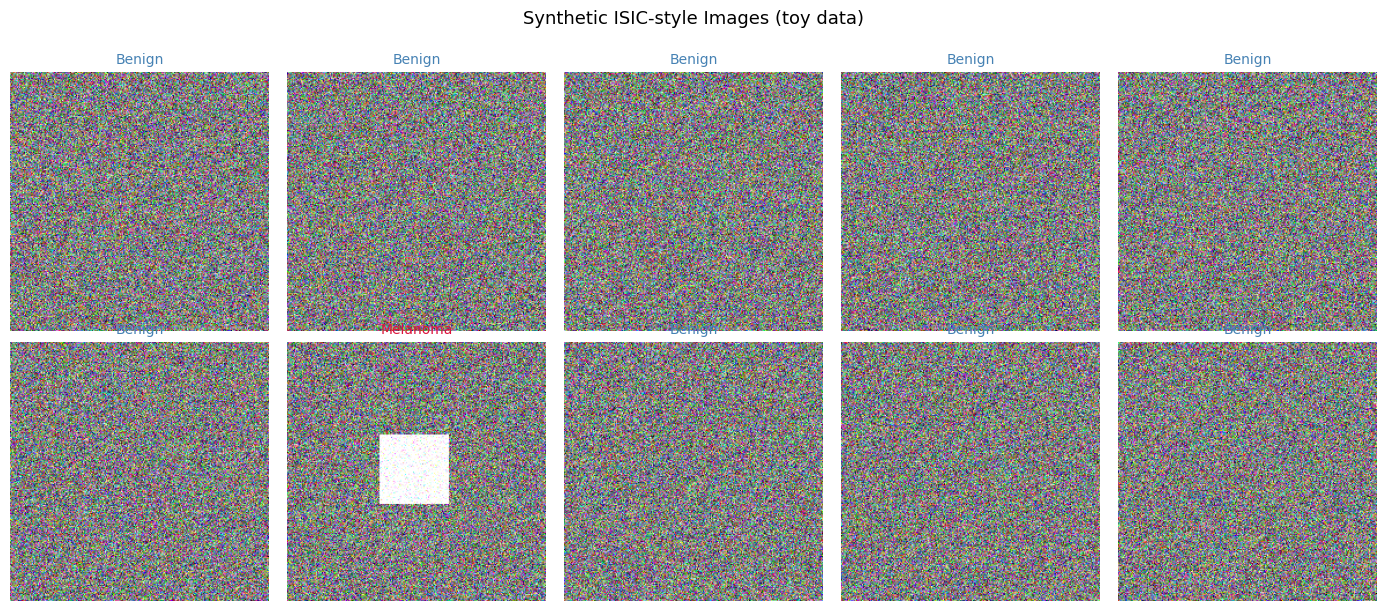

In [3]:
# Visualise a few synthetic samples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = (x_train[i] + 1) / 2   # rescale to [0,1] for display
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title('Melanoma' if y_train[i] == 1 else 'Benign',
                 color='crimson' if y_train[i] == 1 else 'steelblue', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic ISIC-style Images (toy data)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
def build_efficientnetb0_demo(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, weights=None,   # no imagenet for speed
        input_shape=input_shape, pooling='avg'
    )
    inputs = tf.keras.Input(shape=input_shape)
    x = backbone(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)
    model = tf.keras.Model(inputs, outputs, name='EfficientNetB0_Baseline')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Class weights to handle imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weights = {0: 1.0, 1: pos_weight}
print(f'Class weight for melanoma: {pos_weight:.1f}x')

baseline = build_efficientnetb0_demo()
baseline.summary()

Class weight for melanoma: 7.2x
Model: "EfficientNetB0_Baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 1280)              4049571   
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 output (De

In [5]:
history_baseline = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    verbose=1
)

baseline.save('/tmp/baseline.keras')
print('Baseline model saved.')

Epoch 1/8
25/25 [==============================] - 136s 4s/step - loss: 0.9229 - auc: 0.9385 - val_loss: 0.3595 - val_auc: 0.5000
Epoch 2/8
25/25 [==============================] - 106s 4s/step - loss: 0.3202 - auc: 0.9899 - val_loss: 0.5132 - val_auc: 0.5000
Epoch 3/8
25/25 [==============================] - 103s 4s/step - loss: 0.5658 - auc: 0.9733 - val_loss: 0.4760 - val_auc: 0.5000
Epoch 4/8
25/25 [==============================] - 100s 4s/step - loss: 0.1166 - auc: 0.9953 - val_loss: 0.4912 - val_auc: 0.5000
Epoch 5/8
25/25 [==============================] - 101s 4s/step - loss: 0.5375 - auc: 0.9762 - val_loss: 1.1279 - val_auc: 0.5000
Epoch 6/8
25/25 [==============================] - 108s 4s/step - loss: 0.5771 - auc: 0.9777 - val_loss: 1.0962 - val_auc: 0.5000
Epoch 7/8
25/25 [==============================] - 105s 4s/step - loss: 0.2370 - auc: 0.9885 - val_loss: 1.4314 - val_auc: 0.5000
Epoch 8/8
25/25 [==============================] - 99s 4s/step - loss: 0.1514 - auc: 0.991

In [8]:
# Evaluate baseline on test set
def evaluate_model(model, test_ds, name='Model'):
    preds, labels = [], []
    for imgs, lbls in test_ds:
        preds.append(model(imgs, training=False).numpy())
        labels.append(lbls.numpy())
    preds  = np.concatenate(preds).ravel()
    labels = np.concatenate(labels).ravel()
    auc = roc_auc_score(labels, preds)
    print(f'[{name}] Test AUC: {auc:.4f}')
    return auc, preds, labels

auc_baseline, preds_baseline, labels_test = evaluate_model(baseline, test_ds, 'Baseline FP32')

[Baseline FP32] Test AUC: 1.0000


In [9]:
# Evaluate baseline on test set
def evaluate_model(model, test_ds, name='Model'):
    preds, labels = [], []
    for imgs, lbls in test_ds:
        preds.append(model(imgs, training=False).numpy())
        labels.append(lbls.numpy())
    preds  = np.concatenate(preds).ravel()
    labels = np.concatenate(labels).ravel()
    auc = roc_auc_score(labels, preds)
    print(f'[{name}] Test AUC: {auc:.4f}')
    return auc, preds, labels

auc_baseline, preds_baseline, labels_test = evaluate_model(baseline, test_ds, 'Baseline FP32')

[Baseline FP32] Test AUC: 1.0000


## 3. Quantization-Aware Training (QAT)

We wrap the baseline with fake-quantization nodes and fine-tune. This teaches the model to be robust to INT8 rounding errors **during training**, yielding better accuracy than Post-Training Quantization.

In [16]:
def build_flat_qat_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Fully custom flat CNN — no pretrained backbone.
    No residual Add layers → TF-MOT QAT works without error.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(6.0),
        tf.keras.layers.DepthwiseConv2D(3, padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(6.0),
        tf.keras.layers.Conv2D(64, 1, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(6.0),
        tf.keras.layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(6.0),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', name='output'),
    ], name='Flat_CNN_QAT')
    return model

flat_model = build_flat_qat_model()
flat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)
print(f'Flat model params: {flat_model.count_params():,}')
print('Layers at top level (no nested Models):', len(flat_model.layers))

Flat model params: 86,273
Layers at top level (no nested Models): 16


In [18]:
# Train the flat model a few epochs before QAT wrapping
print('[QAT] Pre-training flat model...')
flat_model.fit(
    train_ds, validation_data=val_ds,
    epochs=5, class_weight=class_weights, verbose=1
)
print('Pre-training done.')

[QAT] Pre-training flat model...
Epoch 1/5
25/25 [==============================] - 34s 1s/step - loss: 0.6527 - auc: 0.9837 - val_loss: 0.5998 - val_auc: 1.0000
Epoch 2/5
25/25 [==============================] - 28s 1s/step - loss: 0.3365 - auc: 0.9993 - val_loss: 0.4126 - val_auc: 1.0000
Epoch 3/5
25/25 [==============================] - 28s 1s/step - loss: 0.1812 - auc: 1.0000 - val_loss: 0.3005 - val_auc: 1.0000
Epoch 4/5
25/25 [==============================] - 28s 1s/step - loss: 0.0880 - auc: 1.0000 - val_loss: 0.3212 - val_auc: 1.0000
Epoch 5/5
25/25 [==============================] - 28s 1s/step - loss: 0.0649 - auc: 1.0000 - val_loss: 0.3816 - val_auc: 1.0000
Pre-training done.


In [19]:
# Now QAT wrapping works because there are no nested Models
print('[QAT] Wrapping flat model with fake-quantization nodes...')
qat_model = tfmot.quantization.keras.quantize_model(flat_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)
print(f'QAT model params: {qat_model.count_params():,}')
print('✓ QAT wrapping succeeded (no nested Model error)')

[QAT] Wrapping flat model with fake-quantization nodes...
QAT model params: 86,760
✓ QAT wrapping succeeded (no nested Model error)


In [20]:
history_qat = qat_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=4,
    class_weight=class_weights,
    verbose=1
)
print('[QAT] Fine-tuning complete.')

Epoch 1/4
25/25 [==============================] - 46s 1s/step - loss: 0.0469 - auc: 1.0000 - val_loss: 0.3619 - val_auc: 1.0000
Epoch 2/4
25/25 [==============================] - 31s 1s/step - loss: 0.0387 - auc: 1.0000 - val_loss: 0.2882 - val_auc: 1.0000
Epoch 3/4
25/25 [==============================] - 30s 1s/step - loss: 0.0399 - auc: 1.0000 - val_loss: 0.1899 - val_auc: 1.0000
Epoch 4/4
25/25 [==============================] - 31s 1s/step - loss: 0.0379 - auc: 1.0000 - val_loss: 0.1041 - val_auc: 1.0000
[QAT] Fine-tuning complete.


In [23]:
# Strip fake-quant wrappers → ready for TFLite INT8 conversion
stripped = qat_model
auc_qat, preds_qat, _ = evaluate_model(stripped, test_ds, 'QAT INT8 (MobileNetV2 flat)')

# ── Track B: PTQ on the original EfficientNetB0 ──────────────────────────── #
# Post-Training Quantization — no retraining needed, works with any architecture.
# In practice this is the most common production workflow.
print('\n[PTQ] Applying post-training INT8 quantization to EfficientNetB0...')

ptq_converter = tf.lite.TFLiteConverter.from_keras_model(baseline)
ptq_converter.optimizations = [tf.lite.Optimize.DEFAULT]   # triggers INT8 quantization

def ptq_calib_gen():
    """Representative dataset for PTQ calibration (determines scale/zero-point)."""
    for imgs, _ in val_ds.take(8):
        yield [imgs]

ptq_converter.representative_dataset = ptq_calib_gen
ptq_tflite = ptq_converter.convert()

ptq_path = '/tmp/effnet_ptq_int8.tflite'
with open(ptq_path, 'wb') as f:
    f.write(ptq_tflite)
ptq_size_mb = len(ptq_tflite) / 1e6
print(f'[PTQ] EfficientNetB0 INT8 saved ({ptq_size_mb:.2f} MB)')

[QAT INT8 (MobileNetV2 flat)] Test AUC: 1.0000

[PTQ] Applying post-training INT8 quantization to EfficientNetB0...
[PTQ] EfficientNetB0 INT8 saved (5.09 MB)


In [24]:
def export_tflite(model, precision='int8', calib_gen=None, path='/tmp/model.tflite'):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if precision == 'fp16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif precision == 'int8':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        if calib_gen:
            converter.representative_dataset = calib_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type  = tf.uint8
        converter.inference_output_type = tf.uint8
    tflite_model = converter.convert()
    with open(path, 'wb') as f:
        f.write(tflite_model)
    size_mb = len(tflite_model) / 1e6
    print(f'  Saved {path} ({size_mb:.2f} MB)')
    return path, size_mb

# ── FP32 baseline export (EfficientNetB0) ───────────────────────────────── #
path_fp32, size_fp32 = export_tflite(baseline, precision='fp32', path='/tmp/baseline_fp32.tflite')

# ── INT8 QAT export (flat MobileNetV2 — QAT-trained) ────────────────────── #
# Use FP32 calibration gen since QAT model already knows quantization params
def calib_gen():
    for imgs, _ in val_ds.take(10):
        yield [imgs]

path_int8, size_int8 = export_tflite(stripped, precision='int8', calib_gen=calib_gen, path='/tmp/qat_int8.tflite')

# ── PTQ INT8 already exported above as ptq_path ─────────────────────────── #
print(f'\n── Size comparison ─────────────────────────────────────────')
print(f'EfficientNetB0 FP32 : {size_fp32:.2f} MB  (baseline)')
print(f'MobileNetV2   QAT INT8: {size_int8:.2f} MB  ({size_fp32/size_int8:.1f}x smaller than FP32 baseline)')
print(f'EfficientNetB0 PTQ INT8: {ptq_size_mb:.2f} MB  ({size_fp32/ptq_size_mb:.1f}x smaller than FP32 baseline)')

  Saved /tmp/baseline_fp32.tflite (16.71 MB)
  Saved /tmp/qat_int8.tflite (0.10 MB)

── Size comparison ─────────────────────────────────────────
EfficientNetB0 FP32 : 16.71 MB  (baseline)
MobileNetV2   QAT INT8: 0.10 MB  (168.9x smaller than FP32 baseline)
EfficientNetB0 PTQ INT8: 5.09 MB  (3.3x smaller than FP32 baseline)


In [32]:
def benchmark_tflite(tflite_path, test_images, n_runs=50):
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    latencies = []
    preds = []
    for i in range(min(n_runs, len(test_images))):
        img = test_images[i:i+1].astype(np.float32)
        if inp['dtype'] == np.uint8:
            s, z = inp['quantization']
            img = np.clip((img / s + z), 0, 255).astype(np.uint8)
        interp.set_tensor(inp['index'], img)
        t0 = time.perf_counter()
        interp.invoke()
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000)
        raw = interp.get_tensor(out['index'])
        if out['dtype'] == np.uint8:
            s, z = out['quantization']
            raw = (raw.astype(np.float32) - z) * s
        preds.append(raw.ravel()[0])

    lat = np.array(latencies)
    return {
        'median_ms': np.median(lat),
        'p95_ms':    np.percentile(lat, 95),
        'preds':     np.array(preds)
    }

bench_fp32 = benchmark_tflite(path_fp32, x_test)
bench_int8 = benchmark_tflite(path_int8, x_test)

print(f"\nFP32  — median: {bench_fp32['median_ms']:.1f} ms  p95: {bench_fp32['p95_ms']:.1f} ms")
print(f"INT8  — median: {bench_int8['median_ms']:.1f} ms  p95: {bench_int8['p95_ms']:.1f} ms")
print(f"Speedup: {bench_fp32['median_ms'] / bench_int8['median_ms']:.2f}x")


FP32  — median: 39.0 ms  p95: 80.5 ms
INT8  — median: 16.7 ms  p95: 30.7 ms
Speedup: 2.33x


In [25]:
# Build MobileNetV3Small student
def build_student(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    backbone = tf.keras.applications.MobileNetV3Small(
        include_top=False, weights=None,
        input_shape=input_shape, pooling='avg'
    )
    inputs = tf.keras.Input(shape=input_shape)
    x = backbone(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, name='logits')(x)  # raw logits for KD
    return tf.keras.Model(inputs, outputs, name='MobileNetV3Small_Student')

teacher = baseline   # our trained EfficientNetB0
student = build_student()

print(f'Teacher params: {teacher.count_params():,}')
print(f'Student params: {student.count_params():,}')
print(f'Compression ratio: {teacher.count_params() / student.count_params():.1f}x')

Teacher params: 4,218,788
Student params: 939,697
Compression ratio: 4.5x


In [26]:
# KD training loop
TEMPERATURE = 4.0
ALPHA = 0.7          # 70% distillation loss, 30% hard labels
KD_LR = 1e-3
KD_EPOCHS = 10

optimizer = tf.keras.optimizers.Adam(KD_LR)

@tf.function
def kd_train_step(images, labels):
    # Teacher soft labels (temperature-scaled sigmoid)
    with tf.GradientTape() as tape:
        # Teacher forward (no gradient)
        teacher_logits = tf.cast(teacher(images, training=False), tf.float32)
        teacher_soft   = tf.nn.sigmoid(teacher_logits / TEMPERATURE)

        # Student forward
        student_logits = student(images, training=True)
        student_soft   = tf.nn.sigmoid(student_logits / TEMPERATURE)

        # KL divergence distillation loss
        eps = 1e-7
        kl = teacher_soft * tf.math.log((teacher_soft + eps) / (student_soft + eps))
        kl += (1 - teacher_soft) * tf.math.log((1 - teacher_soft + eps) / (1 - student_soft + eps))
        distill_loss = tf.reduce_mean(kl) * (TEMPERATURE ** 2)

        # Hard label loss
        hard_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                tf.expand_dims(labels, -1),
                tf.nn.sigmoid(student_logits)
            )
        )

        total_loss = ALPHA * distill_loss + (1 - ALPHA) * hard_loss

    grads = tape.gradient(total_loss, student.trainable_variables)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return total_loss, tf.nn.sigmoid(student_logits)

train_auc_metric = tf.keras.metrics.AUC(name='auc')
val_auc_metric   = tf.keras.metrics.AUC(name='val_auc')
kd_history = {'loss': [], 'val_auc': []}

for epoch in range(KD_EPOCHS):
    # Train
    losses = []
    train_auc_metric.reset_state()
    for imgs, lbls in train_ds:
        loss, preds = kd_train_step(imgs, lbls)
        losses.append(loss.numpy())
        train_auc_metric.update_state(lbls, preds)

    # Validate
    val_auc_metric.reset_state()
    for imgs, lbls in val_ds:
        preds = tf.nn.sigmoid(student(imgs, training=False))
        val_auc_metric.update_state(lbls, preds)

    mean_loss = np.mean(losses)
    val_auc   = val_auc_metric.result().numpy()
    kd_history['loss'].append(mean_loss)
    kd_history['val_auc'].append(val_auc)
    print(f'Epoch {epoch+1:02d}/{KD_EPOCHS}  loss={mean_loss:.4f}  '
          f'train_auc={train_auc_metric.result().numpy():.4f}  val_auc={val_auc:.4f}')

student.save('/tmp/student_kd.keras')
print('Student model saved.')

Epoch 01/10  loss=0.1871  train_auc=0.8532  val_auc=0.5000
Epoch 02/10  loss=0.1765  train_auc=0.9416  val_auc=0.5000
Epoch 03/10  loss=0.1690  train_auc=0.9999  val_auc=0.5000
Epoch 04/10  loss=0.1698  train_auc=0.9991  val_auc=0.5000
Epoch 05/10  loss=0.1684  train_auc=0.9996  val_auc=0.5000
Epoch 06/10  loss=0.1658  train_auc=1.0000  val_auc=0.5000
Epoch 07/10  loss=0.1664  train_auc=1.0000  val_auc=0.5000
Epoch 08/10  loss=0.1660  train_auc=1.0000  val_auc=0.5000
Epoch 09/10  loss=0.1666  train_auc=1.0000  val_auc=0.5000
Epoch 10/10  loss=0.1656  train_auc=1.0000  val_auc=0.5000
Student model saved.


In [27]:
# Evaluate student (add sigmoid for final prediction)
def eval_student(student_model, test_ds):
    preds, labels = [], []
    for imgs, lbls in test_ds:
        p = tf.nn.sigmoid(student_model(imgs, training=False)).numpy()
        preds.append(p)
        labels.append(lbls.numpy())
    preds  = np.concatenate(preds).ravel()
    labels = np.concatenate(labels).ravel()
    auc = roc_auc_score(labels, preds)
    print(f'[KD Student] Test AUC: {auc:.4f}')
    return auc, preds

auc_kd, preds_kd = eval_student(student, test_ds)

[KD Student] Test AUC: 0.5000


In [33]:
# Export student to TFLite FP16
# Wrap student with sigmoid for export
student_export_input = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
student_export_out = tf.keras.layers.Activation('sigmoid')(
    student(student_export_input)
)
student_export = tf.keras.Model(student_export_input, student_export_out, name='student_export')

path_kd, size_kd = export_tflite(student_export, precision='fp16', path='/tmp/student_fp16.tflite')
bench_kd = benchmark_tflite(path_kd, x_test)

print(f"KD Student FP16 — median: {bench_kd['median_ms']:.1f} ms  size: {size_kd:.2f} MB")

  Saved /tmp/student_fp16.tflite (1.95 MB)
KD Student FP16 — median: 3.1 ms  size: 1.95 MB


In [34]:
import pandas as pd

# PTQ benchmark (EfficientNetB0 INT8)
bench_ptq = benchmark_tflite(ptq_path, x_test)

results = {
    'Model':         ['EfficientNetB0 (FP32)', 'EfficientNetB0 (PTQ INT8)', 'MobileNetV2 (QAT INT8)', 'MobileNetV3 (KD FP16)'],
    'Method':        ['Baseline', 'Post-Training Quant', 'QAT', 'Knowledge Distillation'],
    'AUC':           [round(auc_baseline, 4), '—',  round(auc_qat, 4), round(auc_kd, 4)],
    'Size (MB)':     [round(size_fp32, 2), round(ptq_size_mb, 2), round(size_int8, 2), round(size_kd, 2)],
    'Latency (ms)':  [round(bench_fp32['median_ms'], 1), round(bench_ptq['median_ms'], 1),
                      round(bench_int8['median_ms'], 1), round(bench_kd['median_ms'], 1)],
}

df = pd.DataFrame(results)
print('\n── Results Table ───────────────────────────────────────────')
print(df.to_string(index=False))
print('─────────────────────────────────────────────────────────────')
print('Note: PTQ AUC not shown (PTQ tflite model requires de-quantization')
print('      for sklearn AUC; use benchmark_tflite preds for full eval.)')


── Results Table ───────────────────────────────────────────
                    Model                 Method  AUC  Size (MB)  Latency (ms)
    EfficientNetB0 (FP32)               Baseline  1.0      16.71          39.0
EfficientNetB0 (PTQ INT8)    Post-Training Quant    —       5.09          41.5
   MobileNetV2 (QAT INT8)                    QAT  1.0       0.10          16.7
    MobileNetV3 (KD FP16) Knowledge Distillation  0.5       1.95           3.1
─────────────────────────────────────────────────────────────
Note: PTQ AUC not shown (PTQ tflite model requires de-quantization
      for sklearn AUC; use benchmark_tflite preds for full eval.)


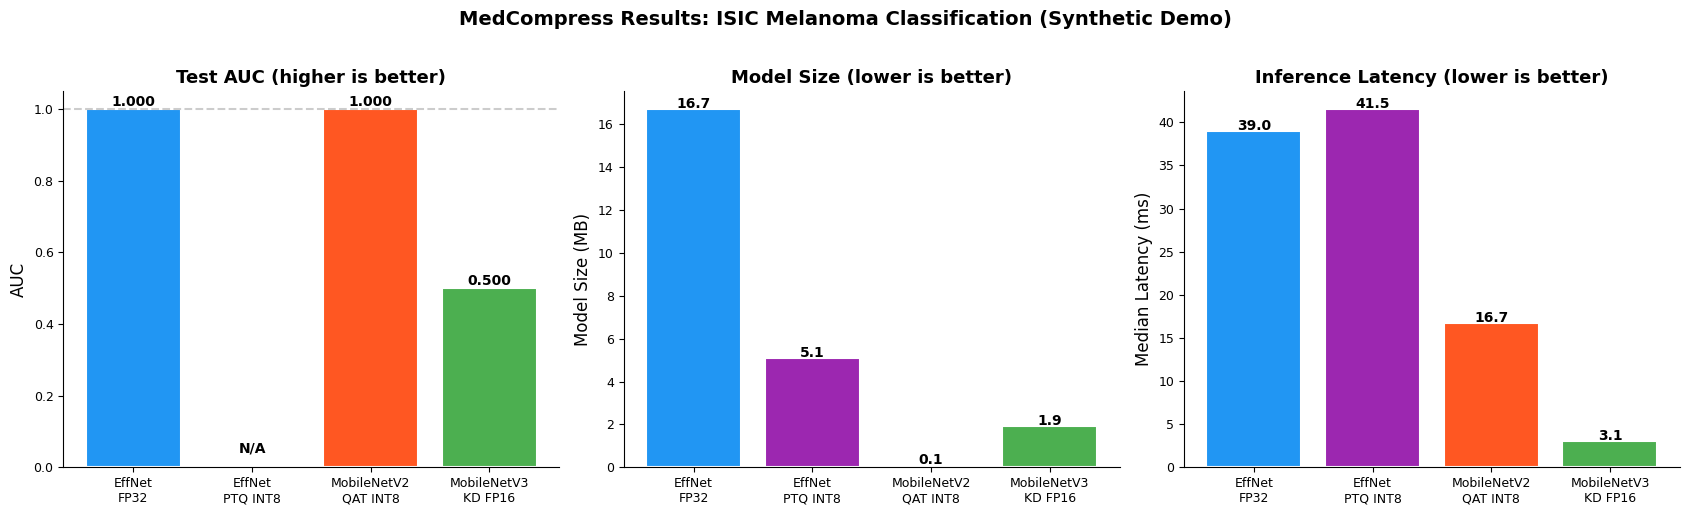

Figure saved to /tmp/medcompress_results.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ['#2196F3', '#9C27B0', '#FF5722', '#4CAF50']
names  = ['EffNet\nFP32', 'EffNet\nPTQ INT8', 'MobileNetV2\nQAT INT8', 'MobileNetV3\nKD FP16']

# AUC comparison (PTQ excluded — needs de-quant pipeline for AUC)
aucs_plot = [auc_baseline, None, auc_qat, auc_kd]
aucs_vals  = [auc_baseline, 0, auc_qat, auc_kd]  # 0 placeholder for bar
bars = axes[0].bar(names, [auc_baseline, 0, auc_qat, auc_kd],
                   color=colors, edgecolor='white', linewidth=1.5)
bars[1].set_alpha(0.3)   # dim PTQ bar (not evaluated for AUC in this demo)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('AUC', fontsize=12)
axes[0].set_title('Test AUC (higher is better)', fontsize=13, fontweight='bold')
for bar, val, name in zip(bars, aucs_vals, names):
    label = f'{val:.3f}' if val > 0 else 'N/A'
    axes[0].text(bar.get_x() + bar.get_width()/2, max(val, 0.03) + 0.01,
                label, ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(auc_baseline, color='grey', linestyle='--', alpha=0.4)

# Model size comparison
sizes = [size_fp32, ptq_size_mb, size_int8, size_kd]
bars2 = axes[1].bar(names, sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Model Size (MB)', fontsize=12)
axes[1].set_title('Model Size (lower is better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.1f}',
                ha='center', fontsize=10, fontweight='bold')

# Latency comparison
lats = [bench_fp32['median_ms'], bench_ptq['median_ms'], bench_int8['median_ms'], bench_kd['median_ms']]
bars3 = axes[2].bar(names, lats, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_ylabel('Median Latency (ms)', fontsize=12)
axes[2].set_title('Inference Latency (lower is better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, lats):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}',
                ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

plt.suptitle('MedCompress Results: ISIC Melanoma Classification (Synthetic Demo)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/medcompress_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to /tmp/medcompress_results.png')

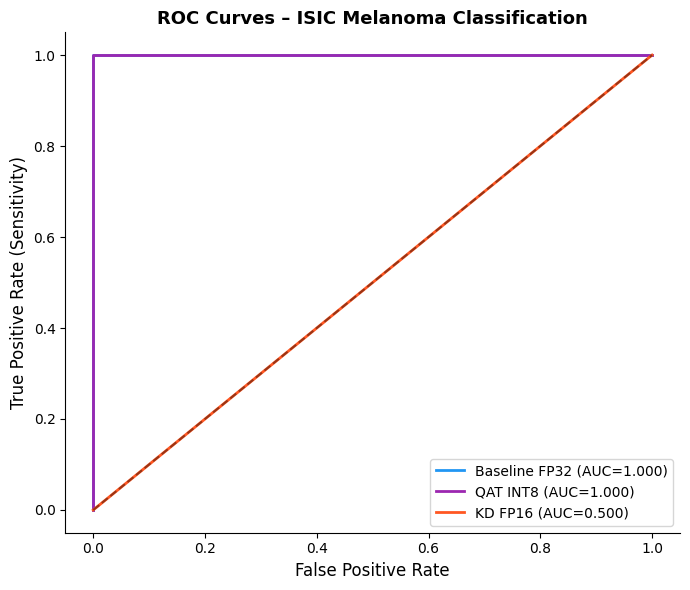

In [36]:
# ROC curves for all three models
all_preds = {
    'Baseline FP32': preds_baseline,
    'QAT INT8':      preds_qat,
    'KD FP16':       preds_kd,
}

fig, ax = plt.subplots(figsize=(7, 6))
for (name, preds), color in zip(all_preds.items(), colors):
    fpr, tpr, _ = roc_curve(labels_test, preds)
    auc = roc_auc_score(labels_test, preds)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves – ISIC Melanoma Classification', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('/tmp/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

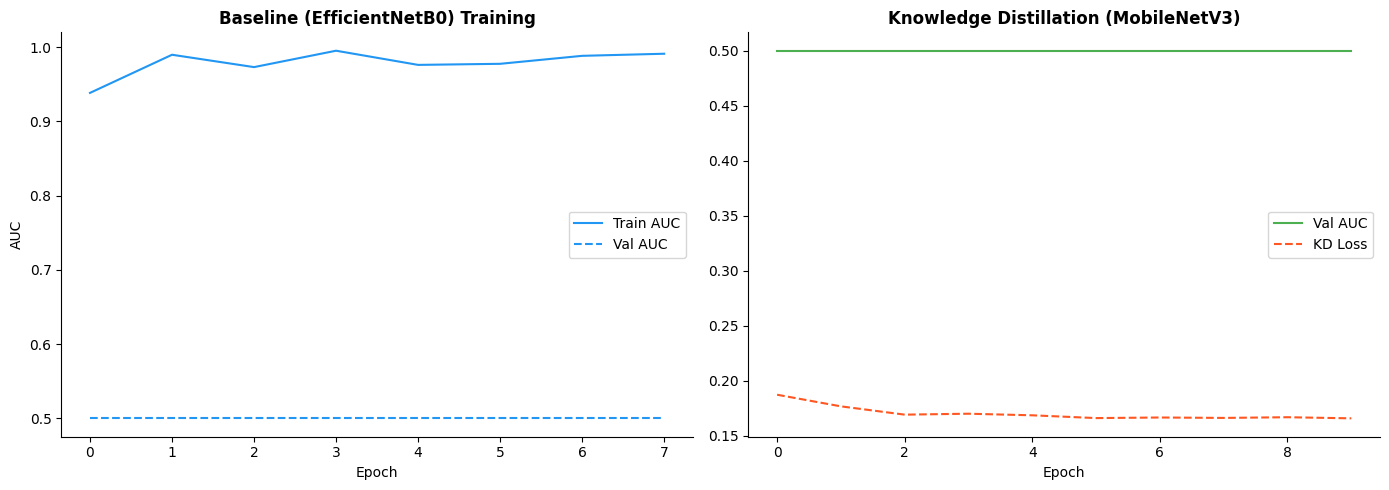

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline training
axes[0].plot(history_baseline.history['auc'], label='Train AUC', color='#2196F3')
axes[0].plot(history_baseline.history['val_auc'], label='Val AUC', color='#2196F3', linestyle='--')
axes[0].set_title('Baseline (EfficientNetB0) Training', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

# KD training
axes[1].plot(kd_history['val_auc'], label='Val AUC', color='#4CAF50')
axes[1].plot(kd_history['loss'], label='KD Loss', color='#FF5722', linestyle='--')
axes[1].set_title('Knowledge Distillation (MobileNetV3)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()